# Benchmark: Modelo de Oscar (v2_actions_rl) — Greedy vs DLTS-LDS vs Beam Search

Compara tres estrategias de búsqueda usando el **branching model** de Oscar (`v2_actions_rl`).

- **Greedy**: sigue siempre el movimiento más probable del modelo. Sin exploración.
- **DLTS-LDS** (Algorithm 2 del paper): explora por número de *discrepancias* respecto al modelo.
  Primero camino puro-greedy (0 desviaciones), luego con 1 desviación, luego 2, etc.
  Usa además el bounding model (`v2_cost`) para podar ramas.
- **Beam Search** (W=32): mantiene los 32 mejores estados por log-probabilidad acumulada.

**Referencia:** Hottung, Tanaka, Tierney (2020) — *Deep learning assisted heuristic tree search
for the container pre-marshalling problem*. Algorithm 2: DLTS-LDS.

In [1]:
import sys, os, json, copy, time
import torch
import numpy as np

MAIN_SRC  = os.path.abspath('../src')
REPO_SRC  = os.path.abspath('../Repo_Oscar/CPMP-Framework/src')
MODEL_DIR = os.path.abspath('../models')

# Fase 1: main src (solvers, cpmp, training)
sys.path.insert(0, MAIN_SRC)

from training.training import load_model
from solvers.model import ModelSolver
from solvers.dlts_lds import DLTSLDSSolver
from solvers.beam_search import BeamSearchSolver
from cpmp.layout import read_file
from settings import INSTANCE_FOLDER

print('Main src OK')

# Fase 2: limpiar generation y cargar Repo_Oscar (modelo V2 + adapters)
for k in [k for k in sys.modules if k == 'generation' or k.startswith('generation.')]:
    del sys.modules[k]
sys.path.insert(0, REPO_SRC)

from models.actions.cpmp_transformer_V2 import CPMPTransformer as OscarCPMPTransformer
from models.cost.cost_predictor_V2 import CostPredictorTransformer
from generation.adapters.input.enriched_layout_adapter import EnrichedLayoutAdapter
from generation.adapters.input.layout.layout_4D_adapter_V2 import Layout4DAdapterV2
from generation.adapters.input.stack_features.stack_features_adapter_V1 import StackFeaturesAdapterV1

print('Repo_Oscar OK')
print('Listo.')

Main src OK
Repo_Oscar OK
Listo.


In [2]:
# ── Adapter: adapta el nombre input_2_vec → layout_2_vec ─────────────────────
class OscarV2LayoutAdapter:
    def __init__(self, S_max, H_max):
        self._inner = EnrichedLayoutAdapter(
            layout_adapter=Layout4DAdapterV2,
            stack_features_adapter=StackFeaturesAdapterV1,
            S_max=S_max, H_max=H_max
        )
        self.S_max = S_max
    def layout_2_vec(self, layout, H):
        return self._inner.input_2_vec(layout, H)

# ── Wrapper: remapea logits de S_max*(S_max-1) a S*(S-1) ─────────────────────
class OscarV2Wrapper(torch.nn.Module):
    def __init__(self, model, S_max):
        super().__init__()
        self._model = model
        self.S_max  = S_max
        self.hyperparams = model.hyperparams

    def forward(self, L, X, S, H):
        logits_full = self._model(L, X, S, H)          # [batch, S_max*(S_max-1)]
        S_int = int(S.item())
        batch = logits_full.shape[0]
        out   = torch.zeros(batch, S_int * (S_int - 1), device=logits_full.device)
        for src in range(S_int):
            for dst in range(S_int):
                if src == dst:
                    continue
                d_off = dst if dst < src else dst - 1
                oscar_idx  = src * (self.S_max - 1) + d_off
                solver_idx = src * (S_int - 1)      + d_off
                out[:, solver_idx] = logits_full[:, oscar_idx]
        return out

# ── Cargar modelos ────────────────────────────────────────────────────────────
S_MAX, H_MAX = 10, 12
_oscar_base     = load_model(OscarCPMPTransformer, 'v2_actions_rl')
branching_model = OscarV2Wrapper(_oscar_base, S_max=S_MAX)
branching_model.layout_adapter = OscarV2LayoutAdapter(S_max=S_MAX, H_max=H_MAX)
branching_model.eval()

def load_cost_model(name):
    hp = json.load(open(os.path.join(MODEL_DIR, 'hyperparameters', f'{name}.json')))
    m = CostPredictorTransformer(**hp)
    m.load_state_dict(torch.load(os.path.join(MODEL_DIR, f'{name}.pth'),
                                  weights_only=True, map_location='cpu'))
    m.eval()
    return m

bounding_model = load_cost_model('v2_cost')

bounding_adapter = EnrichedLayoutAdapter(
    layout_adapter=Layout4DAdapterV2,
    stack_features_adapter=StackFeaturesAdapterV1,
    S_max=S_MAX, H_max=H_MAX
)

hp = branching_model.hyperparams
print(f'Branching: v2_actions_rl  H_dim={hp["H_dim"]}, d_model={hp["d_model"]}, '
      f'nhead={hp["nhead"]}, num_layers={hp["num_layers"]}')
print(f'Bounding : v2_cost  (branching + bounding para DLTS-LDS)')

Branching: v2_actions_rl  H_dim=12, d_model=64, nhead=4, num_layers=4
Bounding : v2_cost  (branching + bounding para DLTS-LDS)


In [3]:
# ── Instanciar solvers ────────────────────────────────────────────────────────
T_LIM = 15.0  # tiempo límite por instancia (segundos)
W     = 32    # beam width

greedy_solver = ModelSolver(branching_model)

lds_solver = DLTSLDSSolver(
    branching_model=branching_model,
    bounding_model=bounding_model,
    bounding_adapter=bounding_adapter,
    p=0.3, k=3, d=0.8, z=0, time_limit=T_LIM
)

beam_solver = BeamSearchSolver(
    branching_model=branching_model,
    beam_width=W,
    expansions_per_state=W,
    time_limit=T_LIM
)

print('Solvers listos:')
print(f'  Greedy     : ModelSolver  (solo branching model)')
print(f'  DLTS-LDS   : p={lds_solver.p}, k={lds_solver.k}, d={lds_solver.d}, z={lds_solver.z}, time_limit={lds_solver.time_limit}s')
print(f'  Beam Search: W={beam_solver.beam_width}, exp/estado={beam_solver.expansions_per_state}, time_limit={beam_solver.time_limit}s')

Solvers listos:
  Greedy     : ModelSolver  (solo branching model)
  DLTS-LDS   : p=0.3, k=3, d=0.8, z=0, time_limit=15.0s
  Beam Search: W=32, exp/estado=32, time_limit=15.0s


In [4]:
# ── Utilidades ────────────────────────────────────────────────────────────────
def avg(vals, mask=None):
    data = [v for v, ok in zip(vals, mask or [True]*len(vals)) if ok]
    return sum(data) / len(data) if data else float('nan')

def run_solver(solver, files, H_inf, max_steps):
    solved_list, steps_list, time_list = [], [], []
    for path in files:
        layout = read_file(path, H_inf)
        t0 = time.perf_counter()
        try:
            solved, steps = solver.solve_from_layout(layout, H_inf, max_steps)
        except Exception:
            solved, steps = False, max_steps
        elapsed = time.perf_counter() - t0
        solved_list.append(solved)
        steps_list.append(steps)
        time_list.append(elapsed)
    return solved_list, steps_list, time_list

print('Utilidades definidas.')

Utilidades definidas.


## Benchmark por categorías CVS

In [5]:
CVS_PATH  = INSTANCE_FOLDER / 'benchmarks' / 'CVS'
MAX_STEPS = 100
N_PER_CAT = 20

ALL_CATS = sorted([d for d in os.listdir(CVS_PATH)
                   if (CVS_PATH / d).is_dir() and not d.startswith('10-')])

SEP = '-' * 120
print(f"{'Cat':>6} {'H':>3} {'S':>3}  "
      f"{'Greedy':>7} {'pasos':>6} {'t(s)':>6}  "
      f"{'DLTS-LDS':>8} {'pasos':>6} {'t(s)':>6}  "
      f"{'BeamW=32':>8} {'pasos':>6} {'t(s)':>6}  "
      f"{'LDS>G':>5} {'Beam>G':>6} {'LDS>B':>6}")
print(SEP)

all_results = {}

for folder_name in ALL_CATS:
    H_r, S_r = [int(x) for x in folder_name.split('-')]
    H_inf = H_r + 2
    folder_path = CVS_PATH / folder_name
    files = sorted([str(folder_path / f)
                    for f in os.listdir(folder_path) if f.endswith('.dat')])[:N_PER_CAT]
    if not files:
        continue

    s_g, st_g, t_g = run_solver(greedy_solver, files, H_inf, MAX_STEPS)
    s_l, st_l, t_l = run_solver(lds_solver,    files, H_inf, MAX_STEPS)
    s_b, st_b, t_b = run_solver(beam_solver,   files, H_inf, MAX_STEPS)

    all_results[folder_name] = dict(
        s_g=s_g, st_g=st_g, t_g=t_g,
        s_l=s_l, st_l=st_l, t_l=t_l,
        s_b=s_b, st_b=st_b, t_b=t_b,
    )

    n = len(files)
    ng, nl, nb_ = sum(s_g), sum(s_l), sum(s_b)

    lds_beats_g  = sum(1 for ok_l, ok_g, pl, pg in zip(s_l, s_g, st_l, st_g)
                       if ok_l and ok_g and pl < pg)
    beam_beats_g = sum(1 for ok_b, ok_g, pb, pg in zip(s_b, s_g, st_b, st_g)
                       if ok_b and ok_g and pb < pg)
    lds_beats_b  = sum(1 for ok_l, ok_b, pl, pb in zip(s_l, s_b, st_l, st_b)
                       if ok_l and ok_b and pl < pb)

    print(f"{folder_name:>6} {H_r:>3} {S_r:>3}  "
          f"{ng:>3}/{n:<2} {avg(st_g,s_g):>6.1f} {avg(t_g,s_g):>6.3f}  "
          f"{nl:>3}/{n:<2} {avg(st_l,s_l):>6.1f} {avg(t_l,s_l):>6.2f}  "
          f"{nb_:>3}/{n:<2} {avg(st_b,s_b):>6.1f} {avg(t_b,s_b):>6.2f}  "
          f"{lds_beats_g:>5} {beam_beats_g:>6} {lds_beats_b:>6}")

print(SEP)

all_sg  = [s for r in all_results.values() for s in r['s_g']]
all_stg = [s for r in all_results.values() for s in r['st_g']]
all_sl  = [s for r in all_results.values() for s in r['s_l']]
all_stl = [s for r in all_results.values() for s in r['st_l']]
all_sb  = [s for r in all_results.values() for s in r['s_b']]
all_stb = [s for r in all_results.values() for s in r['st_b']]
all_tg  = [s for r in all_results.values() for s in r['t_g']]
all_tl  = [s for r in all_results.values() for s in r['t_l']]
all_tb  = [s for r in all_results.values() for s in r['t_b']]
n_tot = len(all_sg)

print(f"{'TOTAL':>6} {'':>3} {'':>3}  "
      f"{sum(all_sg):>3}/{n_tot:<2} {avg(all_stg,all_sg):>6.1f} {avg(all_tg,all_sg):>6.3f}  "
      f"{sum(all_sl):>3}/{n_tot:<2} {avg(all_stl,all_sl):>6.1f} {avg(all_tl,all_sl):>6.2f}  "
      f"{sum(all_sb):>3}/{n_tot:<2} {avg(all_stb,all_sb):>6.1f} {avg(all_tb,all_sb):>6.2f}")

   Cat   H   S   Greedy  pasos   t(s)  DLTS-LDS  pasos   t(s)  BeamW=32  pasos   t(s)  LDS>G Beam>G  LDS>B
------------------------------------------------------------------------------------------------------------------------
   3-3   3   3   20/20   11.1  0.017   20/20   10.3   0.05   20/20    9.8   0.38      6     10      0
   3-4   3   4   20/20    9.2  0.013   20/20    8.8   0.04   20/20    8.8   0.37      5      6      0
   3-5   3   5   20/20   10.8  0.016   20/20   10.6   0.12   20/20   10.4   0.53      5      8      1
   3-6   3   6   20/20   12.1  0.017   20/20   11.8   0.59   20/20   11.7   0.71      6      8      2
   3-7   3   7   20/20   13.2  0.020   20/20   12.9   2.02   20/20   13.1   0.89      5      2      3
   3-8   3   8   20/20   13.6  0.021   20/20   13.2   4.54   20/20   13.2   0.94      6      8      3
   4-4   4   4   20/20   18.9  0.026   20/20   16.8   0.51   20/20   16.4   0.78     16     17      2
   4-5   4   5   20/20   19.5  0.028   20/20   18.4   2.38

## Resumen numérico

In [6]:
# Solo instancias donde los 3 resolvieron
mask3 = [a and b and c for a, b, c in zip(all_sg, all_sl, all_sb)]
n3 = sum(mask3)

st_g3 = [s for s, ok in zip(all_stg, mask3) if ok]
st_l3 = [s for s, ok in zip(all_stl, mask3) if ok]
st_b3 = [s for s, ok in zip(all_stb, mask3) if ok]

print(f'Instancias donde los 3 solvers resolvieron: {n3}')
print()
print(f'  Greedy     : avg pasos = {np.mean(st_g3):.2f}')
print(f'  DLTS-LDS   : avg pasos = {np.mean(st_l3):.2f}  ({(np.mean(st_l3)/np.mean(st_g3)-1)*100:+.1f}% vs greedy)')
print(f'  Beam Search: avg pasos = {np.mean(st_b3):.2f}  ({(np.mean(st_b3)/np.mean(st_g3)-1)*100:+.1f}% vs greedy)')
print()

l_beats_b = sum(1 for l, b in zip(st_l3, st_b3) if l < b)
b_beats_l = sum(1 for l, b in zip(st_l3, st_b3) if b < l)
equal     = sum(1 for l, b in zip(st_l3, st_b3) if l == b)
print(f'DLTS-LDS vs Beam Search (en las {n3} instancias comunes):')
print(f'  LDS mejor  : {l_beats_b:>4} ({l_beats_b/n3:>5.1%})')
print(f'  Igual       : {equal:>4} ({equal/n3:>5.1%})')
print(f'  Beam mejor  : {b_beats_l:>4} ({b_beats_l/n3:>5.1%})')

Instancias donde los 3 solvers resolvieron: 380

  Greedy     : avg pasos = 27.18
  DLTS-LDS   : avg pasos = 25.08  (-7.7% vs greedy)
  Beam Search: avg pasos = 25.60  (-5.8% vs greedy)

DLTS-LDS vs Beam Search (en las 380 instancias comunes):
  LDS mejor  :  154 (40.5%)
  Igual       :  173 (45.5%)
  Beam mejor  :   53 (13.9%)


## Visualización

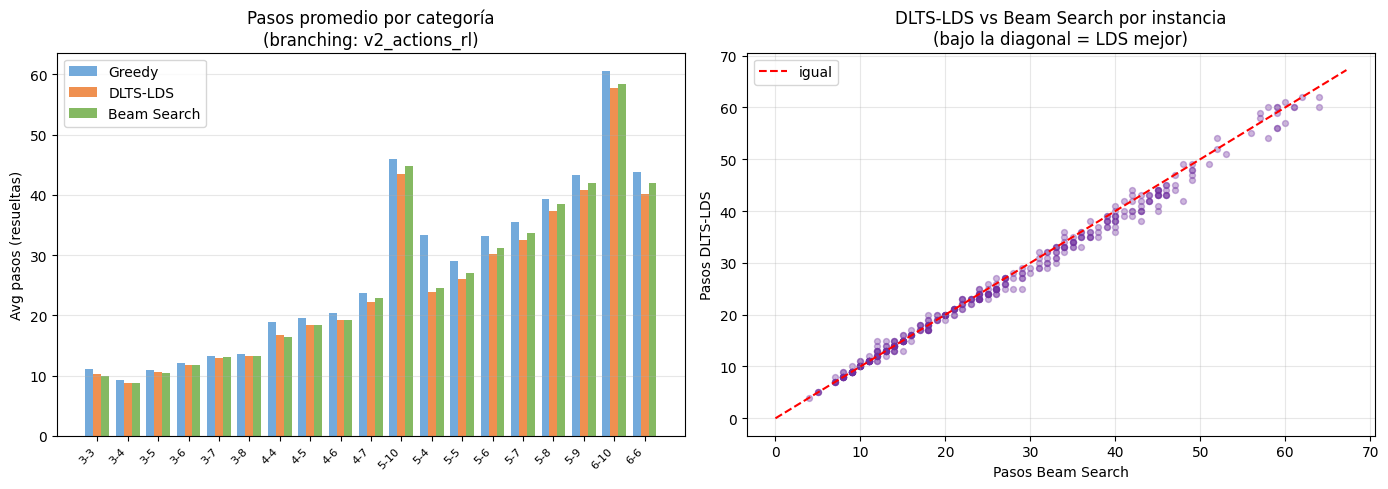

In [7]:
import matplotlib.pyplot as plt

cats_ok = [c for c in all_results if all_results[c]['s_g'] and all_results[c]['s_l']]
cats_sorted = sorted(cats_ok)

avg_g = [avg(all_results[c]['st_g'], all_results[c]['s_g']) for c in cats_sorted]
avg_l = [avg(all_results[c]['st_l'], all_results[c]['s_l']) for c in cats_sorted]
avg_b = [avg(all_results[c]['st_b'], all_results[c]['s_b']) for c in cats_sorted]

x = np.arange(len(cats_sorted))
width = 0.26

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Pasos promedio por categoría ─────────────────────────────────────────────
ax = axes[0]
ax.bar(x - width, avg_g, width, label='Greedy',      color='#5b9bd5', alpha=0.85)
ax.bar(x,         avg_l, width, label='DLTS-LDS',    color='#ed7d31', alpha=0.85)
ax.bar(x + width, avg_b, width, label='Beam Search', color='#70ad47', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(cats_sorted, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Avg pasos (resueltas)')
ax.set_title('Pasos promedio por categoría\n(branching: v2_actions_rl)')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# ── Scatter LDS vs Beam (por instancia) ──────────────────────────────────────
steps_l_all = [s for r in all_results.values()
               for ok_l, ok_b, s in zip(r['s_l'], r['s_b'], r['st_l'])
               if ok_l and ok_b]
steps_b_all = [s for r in all_results.values()
               for ok_l, ok_b, s in zip(r['s_l'], r['s_b'], r['st_b'])
               if ok_l and ok_b]

ax2 = axes[1]
ax2.scatter(steps_b_all, steps_l_all, alpha=0.35, s=18, color='#7030a0')
mx = max(max(steps_l_all), max(steps_b_all)) * 1.05
ax2.plot([0, mx], [0, mx], 'r--', lw=1.5, label='igual')
ax2.set_xlabel('Pasos Beam Search')
ax2.set_ylabel('Pasos DLTS-LDS')
ax2.set_title('DLTS-LDS vs Beam Search por instancia\n(bajo la diagonal = LDS mejor)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()